In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder,OneHotEncoder,StandardScaler

In [2]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE,ADASYN

In [3]:
# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


#Evaluation metrics
from sklearn.metrics import accuracy_score,roc_auc_score,f1_score,precision_score,recall_score,r2_score,mean_absolute_error
from sklearn.metrics import confusion_matrix,classification_report

In [4]:
#The dataset was loaded into a Pandas DataFrame for analysis and preprocessing.

liver_df=pd.read_csv(r'E:\DS\PROJECTS\MULTIPLE_DISEASE_PREDICTION\MULTIPLE_DISEASE_PREDICTION\indian_liver_patient - indian_liver_patient.csv')
liver_df

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [5]:
liver_df.shape

(583, 11)

In [6]:
liver_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [7]:
liver_df.describe(include='all')

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,583.000000,583,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,44.746141,NaN,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,NaN,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,NaN,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,NaN,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,NaN,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,NaN,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000


In [8]:
liver_df['Dataset'].value_counts()

Dataset
1    416
2    167
Name: count, dtype: int64

In [9]:
liver_df.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64

In [10]:
(liver_df.isnull().sum()/len(liver_df))*100

Age                           0.000000
Gender                        0.000000
Total_Bilirubin               0.000000
Direct_Bilirubin              0.000000
Alkaline_Phosphotase          0.000000
Alamine_Aminotransferase      0.000000
Aspartate_Aminotransferase    0.000000
Total_Protiens                0.000000
Albumin                       0.000000
Albumin_and_Globulin_Ratio    0.686106
Dataset                       0.000000
dtype: float64

In [11]:
imputer=SimpleImputer(strategy='median')
liver_df[['Albumin_and_Globulin_Ratio']]=imputer.fit_transform(liver_df[['Albumin_and_Globulin_Ratio']])

#Handling the Null values using imputer process

In [12]:
liver_df.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Dataset                       0
dtype: int64

In [13]:
liver_df.duplicated().sum()

np.int64(13)

In [14]:
liver_df.drop_duplicates(inplace=True)

#The dataset contained 13 duplicate records, which were removed to prevent data redundancy and potential bias during model training.
#The updated dataset contains 570 unique records


In [15]:
liver_df.duplicated().sum()

np.int64(0)

In [16]:
liver_df.columns

Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Dataset'],
      dtype='object')

In [17]:
liver_df['Gender'].value_counts()

Gender
Male      430
Female    140
Name: count, dtype: int64

In [18]:
liver_df['Gender']=liver_df['Gender'].str.strip()
liver_df['Gender']=liver_df['Gender'].map({'Male':1, 'Female':0})

In [19]:
liver_df['Gender'].value_counts()

Gender
1    430
0    140
Name: count, dtype: int64

In [20]:
liver_df['Dataset'].value_counts(normalize=True)*100

#The dataset contains 416 liver disease patients (71.22%) and 167 non-disease patients (28.77%).
#The dataset is moderately imbalanced, with a higher proportion of diseased patients.

Dataset
1    71.22807
2    28.77193
Name: proportion, dtype: float64

In [21]:
liver_df['Dataset']=liver_df['Dataset'].map({1:1,2:0})

#The target variable was converted into binary format where 1 represents liver disease and 0 represents non-disease, enabling binary classification modeling.

In [22]:
liver_df['Dataset'].value_counts()

Dataset
1    406
0    164
Name: count, dtype: int64

In [23]:
liver_df.describe()
liver_df.skew()

Age                           -0.046597
Gender                        -1.185073
Total_Bilirubin                4.869459
Direct_Bilirubin               3.187685
Alkaline_Phosphotase           3.728405
Alamine_Aminotransferase       6.695054
Aspartate_Aminotransferase    10.559418
Total_Protiens                -0.310929
Albumin                       -0.060829
Albumin_and_Globulin_Ratio     1.005967
Dataset                       -0.940320
dtype: float64

In [24]:
skewed_cols = [
    'Total_Bilirubin',
    'Direct_Bilirubin',
    'Alkaline_Phosphotase',
    'Alamine_Aminotransferase',
    'Aspartate_Aminotransferase'
]

for col in skewed_cols:
    liver_df[col] = np.log1p(liver_df[col])

#Several biochemical features exhibited high positive skewness (e.g., AST=10.56). Since these values represent clinically significant extremes
#rather than data errors, log transformation (log1p) was applied to reduce skewness and improve model performance while preserving medical relevance.

In [25]:
liver_df[skewed_cols].skew()

Total_Bilirubin               1.731438
Direct_Bilirubin              1.689599
Alkaline_Phosphotase          1.326397
Alamine_Aminotransferase      1.470664
Aspartate_Aminotransferase    1.246183
dtype: float64

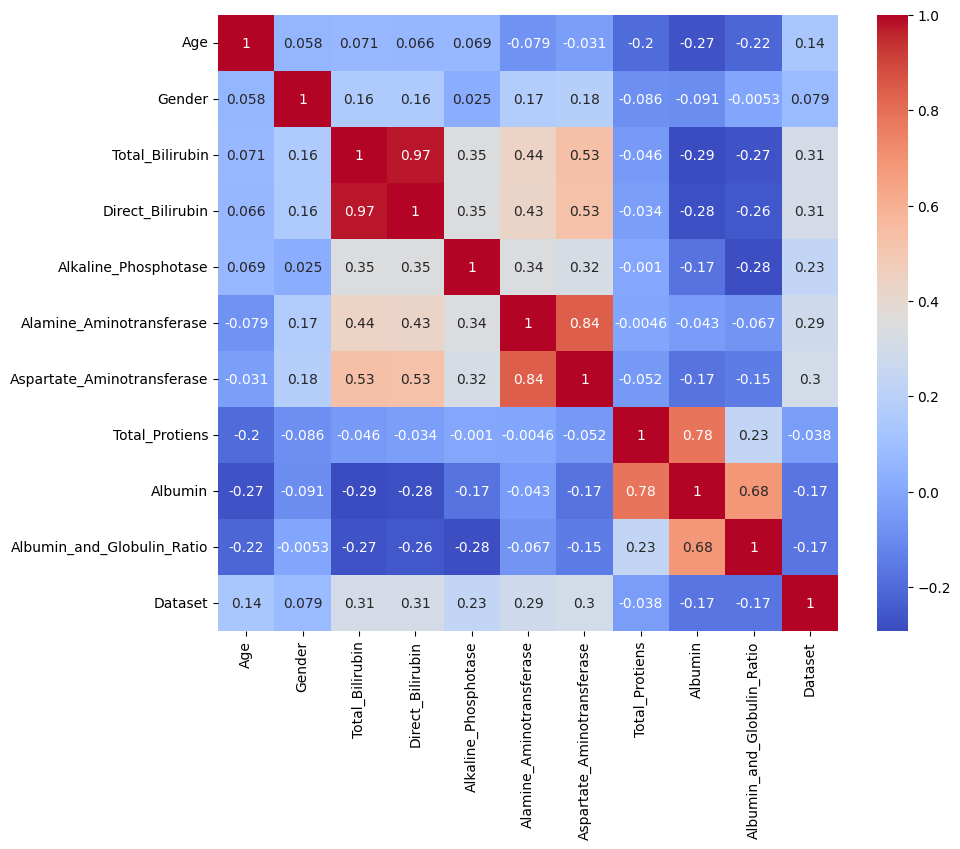

In [26]:
plt.figure(figsize=(10,8))
sns.heatmap(liver_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [27]:
liver_df.corr()['Dataset'].sort_values(ascending=False)

Dataset                       1.000000
Direct_Bilirubin              0.312174
Total_Bilirubin               0.309298
Aspartate_Aminotransferase    0.302103
Alamine_Aminotransferase      0.286356
Alkaline_Phosphotase          0.234744
Age                           0.138093
Gender                        0.078501
Total_Protiens               -0.037794
Albumin                      -0.166835
Albumin_and_Globulin_Ratio   -0.170345
Name: Dataset, dtype: float64

In [28]:
liver_df[skewed_cols].skew()

Total_Bilirubin               1.731438
Direct_Bilirubin              1.689599
Alkaline_Phosphotase          1.326397
Alamine_Aminotransferase      1.470664
Aspartate_Aminotransferase    1.246183
dtype: float64

In [29]:
liver_df.shape

(570, 11)

In [30]:
X = liver_df.drop('Dataset', axis=1)
y = liver_df['Dataset']
X.shape, y.shape

#The feature matrix (X) contains all laboratory and demographic variables, while the target variable (y) 
# represents liver disease status (1 = Disease, 0 = No Disease).

((570, 10), (570,))

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

X_train.shape, X_test.shape

((456, 10), (114, 10))

In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
#Logistic Regression

model = LogisticRegression(max_iter=1000,class_weight='balanced')
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [ ]:
y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7192982456140351

Confusion Matrix:
 [[26  7]
 [25 56]]

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.79      0.62        33
           1       0.89      0.69      0.78        81

    accuracy                           0.72       114
   macro avg       0.70      0.74      0.70       114
weighted avg       0.78      0.72      0.73       114



###### Logistic Regression with class balancing achieved about 72% accuracy and improved detection of the minority class compared to the baseline model.

In [35]:
#Random forest
rf = RandomForestClassifier(class_weight='balanced',random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [36]:
y_pred_rf = rf.predict(X_test)

In [37]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.7105263157894737

Confusion Matrix:
 [[ 6 27]
 [ 6 75]]

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.18      0.27        33
           1       0.74      0.93      0.82        81

    accuracy                           0.71       114
   macro avg       0.62      0.55      0.54       114
weighted avg       0.67      0.71      0.66       114



###### Random Forest achieved ~71% accuracy but showed the highest recall (93%) for detecting liver disease, making it useful for medical screening

In [38]:
#XG BOOSTER

XGB=XGBClassifier()
XGB.fit(X_train,y_train)

y_pred_XGB=XGB.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_XGB))
print("\nConfusion Matrix:\n", confusion_matrix(y_test,y_pred_XGB))
print("\nClassification Report:\n", classification_report(y_test,y_pred_XGB))

Accuracy: 0.7105263157894737

Confusion Matrix:
 [[ 7 26]
 [ 7 74]]

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.21      0.30        33
           1       0.74      0.91      0.82        81

    accuracy                           0.71       114
   macro avg       0.62      0.56      0.56       114
weighted avg       0.67      0.71      0.67       114



###### XGBoost produced similar performance (~71% accuracy) to Random Forest but did not significantly improve overall prediction accuracy

In [39]:
from sklearn.model_selection import GridSearchCV

In [40]:
# Hyperparameter Tuning

param_grid_liver = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [41]:
rf_liver = RandomForestClassifier(random_state=42)

grid_liver = GridSearchCV(
    estimator=rf_liver,
    param_grid=param_grid_liver,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

In [42]:
grid_liver.fit(X_train, y_train)

print("Best Parameters:", grid_liver.best_params_)
print("Best CV Score:", grid_liver.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}
Best CV Score: 0.6929824561403509


In [43]:
best_rf_liver = grid_liver.best_estimator_

y_pred_best_liver = best_rf_liver.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best_liver))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_best_liver))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best_liver))

Accuracy: 0.7105263157894737

Confusion Matrix:
 [[ 6 27]
 [ 6 75]]

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.18      0.27        33
           1       0.74      0.93      0.82        81

    accuracy                           0.71       114
   macro avg       0.62      0.55      0.54       114
weighted avg       0.67      0.71      0.66       114



###### Hyperparameter tuning using GridSearchCV produced a Random Forest model with 71.05% accuracy, maintaining strong recall (93%) for detecting liver disease cases

In [44]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

rf.fit(X_train_bal, y_train_bal)
y_pred_smote = rf.predict(X_test)

print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.48      0.39      0.43        33
           1       0.77      0.83      0.80        81

    accuracy                           0.70       114
   macro avg       0.63      0.61      0.62       114
weighted avg       0.69      0.70      0.69       114



In [56]:
rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_bal, y_train_bal)

# Predict on original test data
y_pred_smote = rf_smote.predict(X_test)

# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_smote))
print("\nClassification Report:\n", classification_report(y_test, y_pred_smote))

Accuracy: 0.7017543859649122

Confusion Matrix:
 [[13 20]
 [14 67]]

Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.39      0.43        33
           1       0.77      0.83      0.80        81

    accuracy                           0.70       114
   macro avg       0.63      0.61      0.62       114
weighted avg       0.69      0.70      0.69       114



###### Applying SMOTE to balance the training data resulted in a Random Forest model with 70% accuracy, improving minority class recall compared to the imbalanced baseline

In [54]:
#SVC
svc = SVC(kernel='rbf', probability=True, class_weight='balanced')
svc.fit(X_train_scaled, y_train)
y_pred_svc = svc.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_svc))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svc))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svc))

Accuracy: 0.7192982456140351

Confusion Matrix:
 [[28  5]
 [27 54]]

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.85      0.64        33
           1       0.92      0.67      0.77        81

    accuracy                           0.72       114
   macro avg       0.71      0.76      0.70       114
weighted avg       0.80      0.72      0.73       114



###### Support Vector Classifier with an RBF kernel achieved ~72% accuracy and provided balanced classification performance between disease and non-disease cases

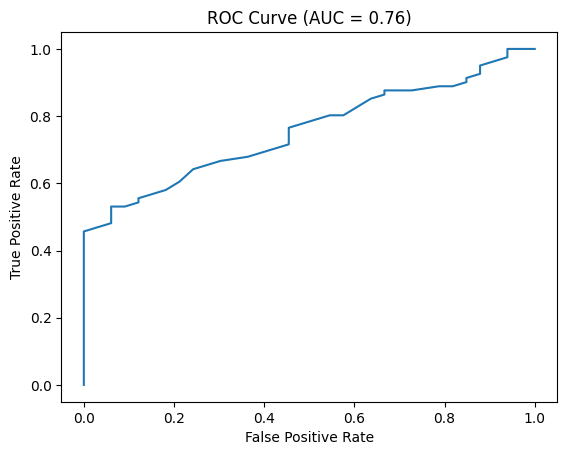

In [47]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.show()


In [48]:
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7551440329218105


###### Model has moderate ability to separate diseased and healthy patients.                                       AUC between 0.7 and 0.8 → acceptable but not excellent.

##### Conclusion                                                                                                    

Multiple machine learning models including Logistic Regression, Random Forest, XGBoost, and Support Vector Classifier were applied to predict liver disease. Techniques such as class balancing, SMOTE, and hyperparameter tuning were used to address class imbalance and improve model performance. The models achieved an overall accuracy of around 70–72%, while the ROC-AUC score of 0.76 indicates a reasonable ability of the model to distinguish between liver disease and non-disease cases. Among the models tested, Random Forest showed strong recall for detecting liver disease, making it suitable for medical screening scenarios where identifying diseased patients is critical.

In [49]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False)

Alkaline_Phosphotase          0.138673
Total_Bilirubin               0.127174
Aspartate_Aminotransferase    0.120797
Alamine_Aminotransferase      0.118215
Direct_Bilirubin              0.113758
Age                           0.109257
Albumin_and_Globulin_Ratio    0.091944
Total_Protiens                0.083493
Albumin                       0.080523
Gender                        0.016165
dtype: float64

In [50]:
import pickle

with open("liver_model.pkl", "wb") as file:
   pickle.dump(rf, file)

In [51]:
with open("liver_scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [52]:
feature_columns_liver = X.columns.tolist()

In [53]:
pickle.dump(feature_columns_liver, open("liver_features.pkl", "wb"))